<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/BIRCHclustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **From Scratch**

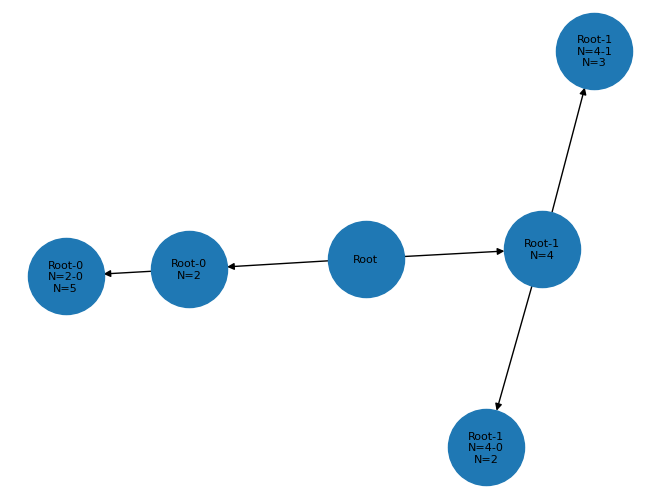

In [1]:
import math
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

# -----------------------------
# CF (Clustering Feature)
# -----------------------------
class CF:
    def __init__(self, point=None):
        if point:
            self.N = 1
            self.LS = list(point)
            self.SS = sum([x**2 for x in point])
            self.points = [point]   # only for visualization
        else:
            self.N = 0
            self.LS = [0, 0]
            self.SS = 0
            self.points = []

    def add_point(self, point):
        self.N += 1
        self.LS[0] += point[0]
        self.LS[1] += point[1]
        self.SS += point[0]**2 + point[1]**2
        self.points.append(point)

    def merge(self, other):
        new_cf = CF()
        new_cf.N = self.N + other.N
        new_cf.LS = [self.LS[0] + other.LS[0],
                     self.LS[1] + other.LS[1]]
        new_cf.SS = self.SS + other.SS
        new_cf.points = self.points + other.points
        return new_cf

    def centroid(self):
        return (self.LS[0] / self.N, self.LS[1] / self.N)

    def radius(self):
        cx, cy = self.centroid()
        val = (self.SS / self.N) - (cx**2 + cy**2)
        return math.sqrt(max(val, 0))

# -----------------------------
# CF Tree Node
# -----------------------------
class Node:
    def __init__(self, is_leaf=True):
        self.is_leaf = is_leaf
        self.children = []
        self.cfs = []
        self.parent = None

# -----------------------------
# BIRCH Tree
# -----------------------------
class BirchTree:
    def __init__(self, B=2, T=2.5):
        self.B = B  # branching factor
        self.T = T  # threshold
        self.root = Node()

    def _distance(self, cf, point):
        cx, cy = cf.centroid()
        return math.sqrt((cx - point[0])**2 + (cy - point[1])**2)

    def _choose_cf(self, node, point):
        min_dist = float('inf')
        best_cf = None
        for cf in node.cfs:
            dist = self._distance(cf, point)
            if dist < min_dist:
                min_dist = dist
                best_cf = cf
        return best_cf

    def insert(self, point):
        node = self.root

        # Traverse to leaf
        while not node.is_leaf:
            best_cf = self._choose_cf(node, point)
            node = node.children[node.cfs.index(best_cf)]

        # Try merging into closest CF
        if node.cfs:
            best_cf = self._choose_cf(node, point)
            new_cf = best_cf.merge(CF(point))

            if new_cf.radius() <= self.T:
                best_cf.add_point(point)
                return

        # Else create new CF
        new_cf = CF(point)
        node.cfs.append(new_cf)

        # Handle overflow
        if len(node.cfs) > self.B:
            self._split(node)

    def _split(self, node):
        # Pick farthest pair as seeds
        max_dist = -1
        seed1, seed2 = None, None

        for i in range(len(node.cfs)):
            for j in range(i+1, len(node.cfs)):
                c1 = node.cfs[i].centroid()
                c2 = node.cfs[j].centroid()
                dist = math.dist(c1, c2)
                if dist > max_dist:
                    max_dist = dist
                    seed1, seed2 = node.cfs[i], node.cfs[j]

        group1 = [seed1]
        group2 = [seed2]

        for cf in node.cfs:
            if cf in (seed1, seed2):
                continue
            d1 = math.dist(cf.centroid(), seed1.centroid())
            d2 = math.dist(cf.centroid(), seed2.centroid())
            if d1 < d2:
                group1.append(cf)
            else:
                group2.append(cf)

        # Create new nodes
        node.cfs = group1
        new_node = Node(is_leaf=node.is_leaf)
        new_node.cfs = group2

        if node == self.root:
            new_root = Node(is_leaf=False)
            new_root.children = [node, new_node]

            new_root.cfs = [
                self._aggregate(node.cfs),
                self._aggregate(new_node.cfs)
            ]

            self.root = new_root
            node.parent = new_root
            new_node.parent = new_root
        else:
            parent = node.parent
            parent.children.append(new_node)
            parent.cfs.append(self._aggregate(new_node.cfs))

    def _aggregate(self, cfs):
        result = CF()
        for cf in cfs:
            result = result.merge(cf)
        return result

# -----------------------------
# Visualization (Tree Graph)
# -----------------------------
def visualize_tree(tree):
    G = nx.DiGraph()
    queue = deque([(tree.root, "Root")])

    while queue:
        node, label = queue.popleft()
        for i, cf in enumerate(node.cfs):
            child_label = f"{label}-{i}\nN={cf.N}"
            G.add_edge(label, child_label)

            if not node.is_leaf:
                queue.append((node.children[i], child_label))

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=3000, font_size=8)
    plt.show()

# -----------------------------
# Run Example
# -----------------------------
points = [(2,3),(3,4),(5,8),(8,7),(7,6),
          (2,2),(6,7),(1,1),(9,8),(8,9)]

tree = BirchTree(B=2, T=2.5)

for p in points:
    tree.insert(p)

visualize_tree(tree)

# **By Using Inbuilt Function**

Labels (No Global Clustering):
[0 0 1 1 1 0 1 0 1 1]

Subcluster Centers:
[[-1.11788859 -1.12986537]
 [ 0.74525906  0.75324358]]

Labels (With Global Clustering):
[1 1 0 0 0 1 0 1 0 0]


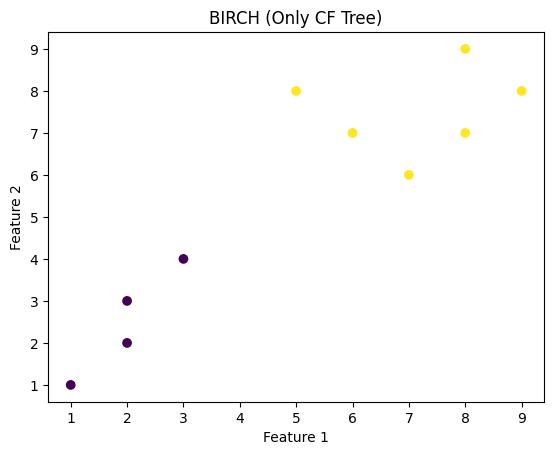

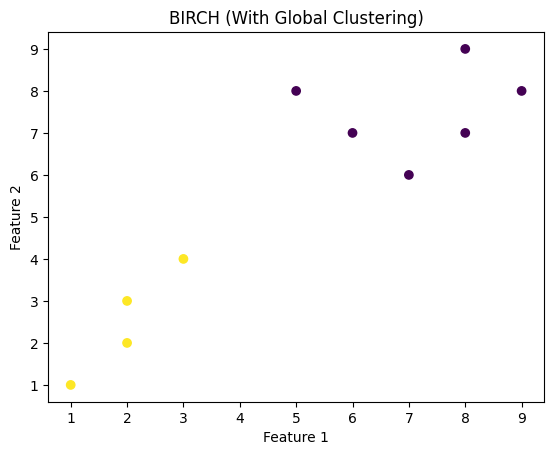

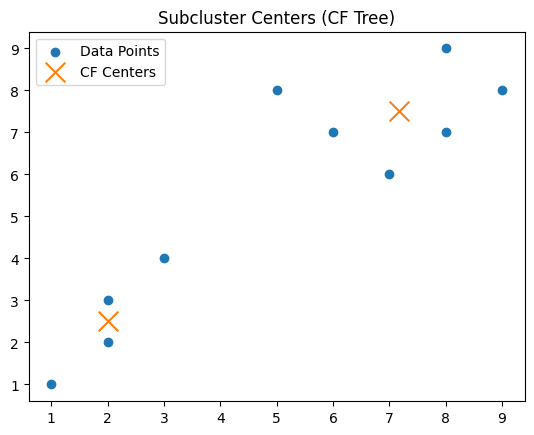

In [2]:
# -------------------------------
# 1. Import Libraries
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import Birch
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 2. Create Dataset
# -------------------------------
X = np.array([
    [2,3],[3,4],[5,8],[8,7],[7,6],
    [2,2],[6,7],[1,1],[9,8],[8,9]
])

# -------------------------------
# 3. Feature Scaling (Important)
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. BIRCH without global clustering
# (Only CF Tree Formation)
# -------------------------------
birch_no_global = Birch(
    threshold=0.8,              # scaled threshold
    branching_factor=2,
    n_clusters=None             # no final clustering
)

birch_no_global.fit(X_scaled)

labels_no_global = birch_no_global.labels_

print("Labels (No Global Clustering):")
print(labels_no_global)

# Subcluster centers (leaf CF nodes)
print("\nSubcluster Centers:")
print(birch_no_global.subcluster_centers_)

# -------------------------------
# 5. BIRCH with global clustering
# (CF Tree + K-Means)
# -------------------------------
birch_global = Birch(
    threshold=0.8,
    branching_factor=2,
    n_clusters=2                # final clusters
)

birch_global.fit(X_scaled)

labels_global = birch_global.labels_

print("\nLabels (With Global Clustering):")
print(labels_global)

# -------------------------------
# 6. Visualization Function
# -------------------------------
def plot_clusters(X, labels, title):
    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# -------------------------------
# 7. Plot Results
# -------------------------------
plot_clusters(X, labels_no_global, "BIRCH (Only CF Tree)")
plot_clusters(X, labels_global, "BIRCH (With Global Clustering)")

# -------------------------------
# 8. Plot Subcluster Centers
# -------------------------------
centers = scaler.inverse_transform(birch_no_global.subcluster_centers_)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], label="Data Points")
plt.scatter(centers[:, 0], centers[:, 1], marker='x', s=200, label="CF Centers")
plt.title("Subcluster Centers (CF Tree)")
plt.legend()
plt.show()